# Transfer Learning sur FashionMNIST
## ResNet18 · EfficientNet-B0 · VGG16 — avec gel partiel des couches

**Problèmes résolus ici :**
- Images grises 28×28 → converties en RGB 224×224
- Normalisation ImageNet appliquée
- Dernière couche remplacée (1000 → 10 classes)
- Gel sélectif des couches (Feature Extraction vs Fine-Tuning)

---
## 1. Imports & Configuration

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device utilisé : {device}")

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
NUM_CLASSES = 10

Device utilisé : cuda


---
## 2. Transformations : adapter FashionMNIST aux modèles ImageNet

Les modèles pré-entraînés sur ImageNet attendent :
- **3 canaux RGB** (FashionMNIST = 1 canal gris)
- **Taille 224×224** (FashionMNIST = 28×28)
- **Normalisation** avec `mean=[0.485, 0.456, 0.406]` et `std=[0.229, 0.224, 0.225]`

Solution : `Resize`, `Grayscale → RGB` via `Lambda`, puis `Normalize`.

In [2]:
# Paramètres de normalisation ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_pretrained = transforms.Compose([
    transforms.Resize((224, 224)),          # 28x28 → 224x224
    transforms.ToTensor(),                  # [0,255] → [0,1]
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # 1 canal → 3 canaux (gris dupliqué)
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # normalisation ImageNet
])

# Chargement des données
train_data = torchvision.datasets.FashionMNIST(
    root='data', train=True, download=True, transform=transform_pretrained)

test_data = torchvision.datasets.FashionMNIST(
    root='data', train=False, download=True, transform=transform_pretrained)

BATCH_SIZE = 64

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train : {len(train_data)} images | {len(train_loader)} batchs")
print(f"Test  : {len(test_data)} images | {len(test_loader)} batchs")

# Vérification de la forme après transformation
sample_img, sample_label = train_data[0]
print(f"\nForme d'une image transformée : {sample_img.shape}")
print(f"Attendu : torch.Size([3, 224, 224])")

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.57MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 62.2MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.6MB/s]


Train : 60000 images | 938 batchs
Test  : 10000 images | 157 batchs

Forme d'une image transformée : torch.Size([3, 224, 224])
Attendu : torch.Size([3, 224, 224])


---
## 3. Fonctions utilitaires : gel des couches, entraînement, évaluation

In [3]:
# ─────────────────────────────────────────────
# Gel / Dégel des couches
# ─────────────────────────────────────────────

def freeze_all(model):
    """Gèle TOUTES les couches (feature extraction pur)."""
    for param in model.parameters():
        param.requires_grad = False

def unfreeze_all(model):
    """Dégèle toutes les couches (fine-tuning complet)."""
    for param in model.parameters():
        param.requires_grad = True

def freeze_n_first_layers(model, n):
    """
    Gèle les n premières couches "enfants" du modèle.
    Les couches après n restent entraînables.
    Utile pour un fine-tuning partiel.
    """
    children = list(model.children())
    print(f"  Nombre total de blocs : {len(children)}")
    for i, child in enumerate(children):
        if i < n:
            for param in child.parameters():
                param.requires_grad = False
            print(f"  [GELÉ]     Bloc {i}: {child.__class__.__name__}")
        else:
            print(f"  [LIBRE]    Bloc {i}: {child.__class__.__name__}")

def count_parameters(model):
    """Affiche le nombre de paramètres entraînables vs total."""
    total    = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Paramètres entraînables : {trainable:>10,}")
    print(f"  Paramètres gelés        : {total - trainable:>10,}")
    print(f"  Total                   : {total:>10,}")
    return trainable, total


# ─────────────────────────────────────────────
# Boucle d'entraînement
# ─────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, 100. * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    return running_loss / total, 100. * correct / total


def train_model(model, train_loader, test_loader, epochs=5, lr=1e-3):
    """Entraîne le modèle et retourne l'historique des métriques."""
    criterion = nn.CrossEntropyLoss()
    # On passe seulement les paramètres qui nécessitent un gradient
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    model.to(device)

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, test_loader, criterion)
        scheduler.step()
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        print(f"  Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.2f}% | "
              f"Val Loss: {va_loss:.4f} Acc: {va_acc:.2f}% | "
              f"{elapsed:.1f}s")
    return history


def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train', marker='o')
    ax1.plot(history['val_loss'],   label='Val',   marker='s')
    ax1.set_title(f'{title} – Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

    ax2.plot(history['train_acc'], label='Train', marker='o')
    ax2.plot(history['val_acc'],   label='Val',   marker='s')
    ax2.set_title(f'{title} – Accuracy (%)')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()
    plt.tight_layout()
    plt.show()

print("Fonctions utilitaires chargées.")

Fonctions utilitaires chargées.


---
## 4. Modèle 1 — ResNet18

### Architecture & stratégie de gel

ResNet18 a la structure suivante :
```
conv1 → bn1 → relu → maxpool
layer1 → layer2 → layer3 → layer4
avgpool → fc (1000 classes)
```
**Stratégie** : on gèle `conv1`, `bn1`, `layer1`, `layer2` (features bas-niveau),
et on laisse libres `layer3`, `layer4`, et le nouveau `fc` (10 classes).

In [4]:
# ── Chargement du modèle pré-entraîné ──────────────────────────────────────
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# ── Étape 1 : geler TOUTES les couches ─────────────────────────────────────
freeze_all(resnet)

# ── Étape 2 : remplacer la dernière couche fc ───────────────────────────────
# resnet.fc était : Linear(512, 1000)
in_features = resnet.fc.in_features   # 512
resnet.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)        # → 10 classes FashionMNIST
)
# La nouvelle tête est automatiquement entraînable (requires_grad=True par défaut)

# ── Étape 3 : dégeler partiellement (layer3 + layer4) ──────────────────────
for param in resnet.layer3.parameters():
    param.requires_grad = True
for param in resnet.layer4.parameters():
    param.requires_grad = True

print("=== ResNet18 — Paramètres ===")
count_parameters(resnet)
resnet = resnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


=== ResNet18 — Paramètres ===
  Paramètres entraînables : 10,627,338
  Paramètres gelés        :    683,072
  Total                   : 11,310,410


In [6]:
print("=== Entraînement ResNet18 ===")
resnet_history = train_model(resnet, train_loader, test_loader, epochs=1, lr=1e-3)

=== Entraînement ResNet18 ===
  Epoch 01/1 | Train Loss: 0.1324 Acc: 95.37% | Val Loss: 0.2027 Acc: 93.37% | 134.1s


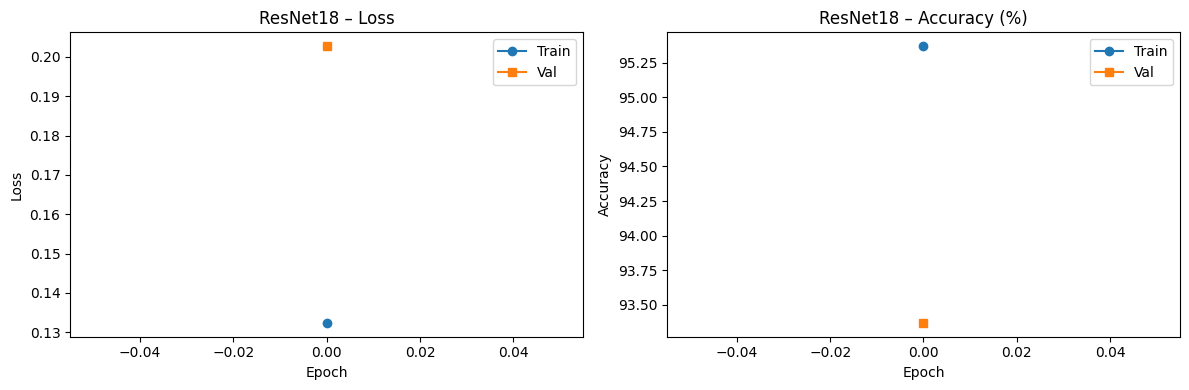

In [10]:
plot_history(resnet_history, 'ResNet18')

---
## 5. Modèle 2 — EfficientNet-B0

EfficientNet-B0 a une structure `features` (séquence de blocs MBConv) + `classifier`.

**Stratégie** : on gèle les 5 premiers blocs de `features` (features génériques),
on laisse libres les 3 derniers blocs + `classifier` (features spécifiques).

In [11]:
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# ── Geler toutes les couches ────────────────────────────────────────────────
freeze_all(efficientnet)

# ── Remplacer le classifier ─────────────────────────────────────────────────
# efficientnet.classifier = [Dropout, Linear(1280, 1000)]
in_features_eff = efficientnet.classifier[1].in_features  # 1280
efficientnet.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_features_eff, 512),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, NUM_CLASSES)
)

# ── Dégeler les 3 derniers blocs de features ────────────────────────────────
features_blocks = list(efficientnet.features.children())
n_total = len(features_blocks)
n_freeze = 5  # geler les 5 premiers blocs sur 9

for i, block in enumerate(features_blocks):
    if i >= n_freeze:
        for param in block.parameters():
            param.requires_grad = True
        print(f"  [LIBRE] features bloc {i}: {block.__class__.__name__}")
    else:
        print(f"  [GELÉ]  features bloc {i}: {block.__class__.__name__}")

print("\n=== EfficientNet-B0 — Paramètres ===")
count_parameters(efficientnet)
efficientnet = efficientnet.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 172MB/s]

  [GELÉ]  features bloc 0: Conv2dNormActivation
  [GELÉ]  features bloc 1: Sequential
  [GELÉ]  features bloc 2: Sequential
  [GELÉ]  features bloc 3: Sequential
  [GELÉ]  features bloc 4: Sequential
  [LIBRE] features bloc 5: Sequential
  [LIBRE] features bloc 6: Sequential
  [LIBRE] features bloc 7: Sequential
  [LIBRE] features bloc 8: Conv2dNormActivation

=== EfficientNet-B0 — Paramètres ===
  Paramètres entraînables :  4,359,890
  Paramètres gelés        :    308,660
  Total                   :  4,668,550


In [12]:
print("=== Entraînement EfficientNet-B0 ===")
efficientnet_history = train_model(efficientnet, train_loader, test_loader, epochs=1, lr=1e-3)

=== Entraînement EfficientNet-B0 ===
  Epoch 01/1 | Train Loss: 0.3124 Acc: 89.00% | Val Loss: 0.2283 Acc: 92.33% | 198.3s


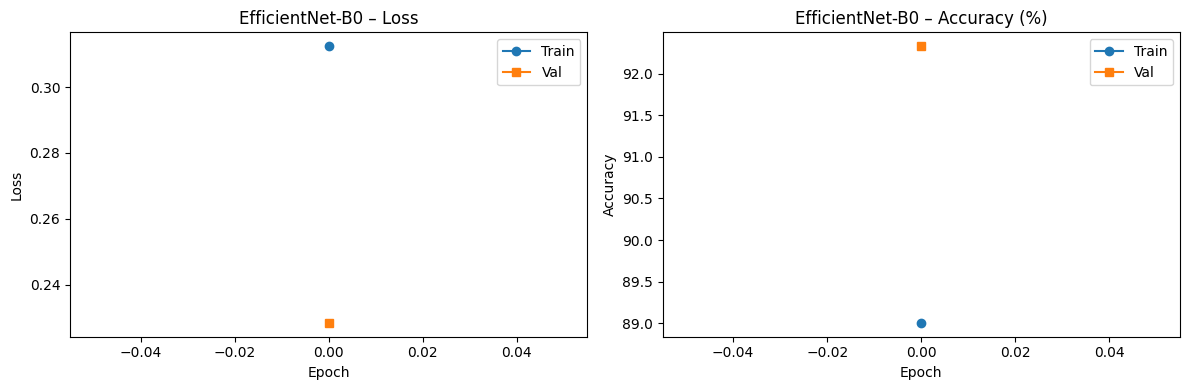

In [13]:
plot_history(efficientnet_history, 'EfficientNet-B0')

---
## 6. Modèle 3 — VGG16

VGG16 a deux parties : `features` (13 couches conv) et `classifier` (3 FC).

**Stratégie** :
- Geler tout `features` (poids conv ImageNet très utiles, ne pas toucher)
- Remplacer entièrement `classifier` par une tête légère pour 10 classes
- Seul le nouveau `classifier` est entraînable → feature extraction pur

In [14]:
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# ── Geler toutes les couches conv (features) ────────────────────────────────
freeze_all(vgg16)  # gèle tout

# ── Remplacer le classifier complet ─────────────────────────────────────────
# VGG16 : features → AdaptiveAvgPool2d → classifier(4096→4096→1000)
# in_features = 512 * 7 * 7 = 25088 après avgpool
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(True),
    nn.Dropout(0.5),
    nn.Linear(1024, 256),
    nn.ReLU(True),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)
# Le nouveau classifier est entraînable par défaut

# ── Option : dégeler les 2 derniers blocs conv de features ──────────────────
# VGG features = [Conv,ReLU,Conv,ReLU,MaxPool] × plusieurs groupes
# On décompose features en liste et on dégèle les éléments finaux
vgg_features = list(vgg16.features.children())
n_features = len(vgg_features)  # 31 couches
freeze_from = 24  # geler layers 0..23, libérer layers 24..30

for i, layer in enumerate(vgg_features):
    if i >= freeze_from:
        for param in layer.parameters():
            param.requires_grad = True

print(f"  VGG16 features: {n_features} couches | gelées: 0→{freeze_from-1} | libres: {freeze_from}→{n_features-1}")
print("\n=== VGG16 — Paramètres ===")
count_parameters(vgg16)
vgg16 = vgg16.to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 71.6MB/s]


  VGG16 features: 31 couches | gelées: 0→23 | libres: 24→30

=== VGG16 — Paramètres ===
  Paramètres entraînables : 33,035,530
  Paramètres gelés        :  7,635,264
  Total                   : 40,670,794


In [15]:
print("=== Entraînement VGG16 ===")
# LR plus faible pour VGG (modèle plus grand, plus sensible)
vgg16_history = train_model(vgg16, train_loader, test_loader, epochs=1, lr=5e-4)

=== Entraînement VGG16 ===


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f2b491589a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f2b491589a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 01/1 | Train Loss: 0.3085 Acc: 89.39% | Val Loss: 0.2487 Acc: 91.37% | 437.8s


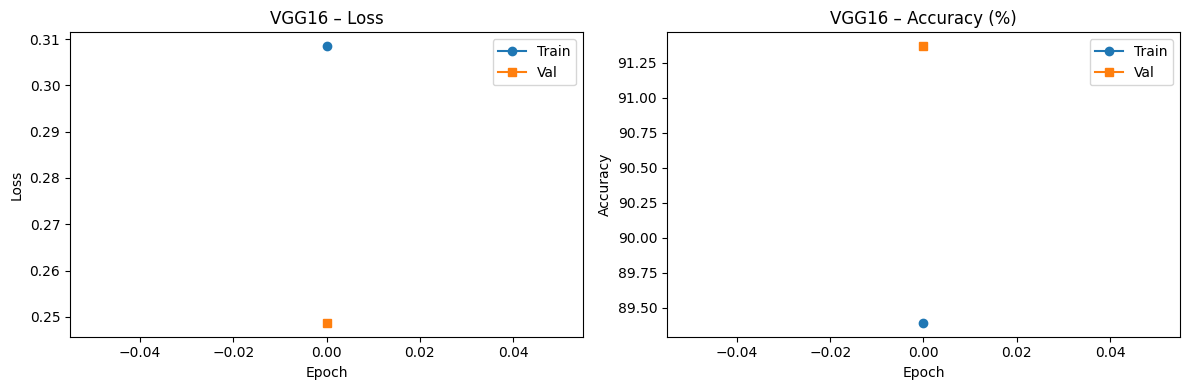

In [16]:
plot_history(vgg16_history, 'VGG16')

---
## 7. Comparaison des 3 modèles

In [17]:
criterion = nn.CrossEntropyLoss()

results = {}
for name, model in [('ResNet18', resnet), ('EfficientNet-B0', efficientnet), ('VGG16', vgg16)]:
    _, acc = evaluate(model, test_loader, criterion)
    trainable, total = (sum(p.numel() for p in model.parameters() if p.requires_grad),
                        sum(p.numel() for p in model.parameters()))
    results[name] = {'acc': acc, 'trainable': trainable, 'total': total}
    print(f"{name:<18} | Accuracy: {acc:.2f}% | Params entraînés: {trainable:,} / {total:,}")

ResNet18           | Accuracy: 93.37% | Params entraînés: 10,627,338 / 11,310,410
EfficientNet-B0    | Accuracy: 92.33% | Params entraînés: 4,359,890 / 4,668,550
VGG16              | Accuracy: 91.37% | Params entraînés: 33,035,530 / 40,670,794


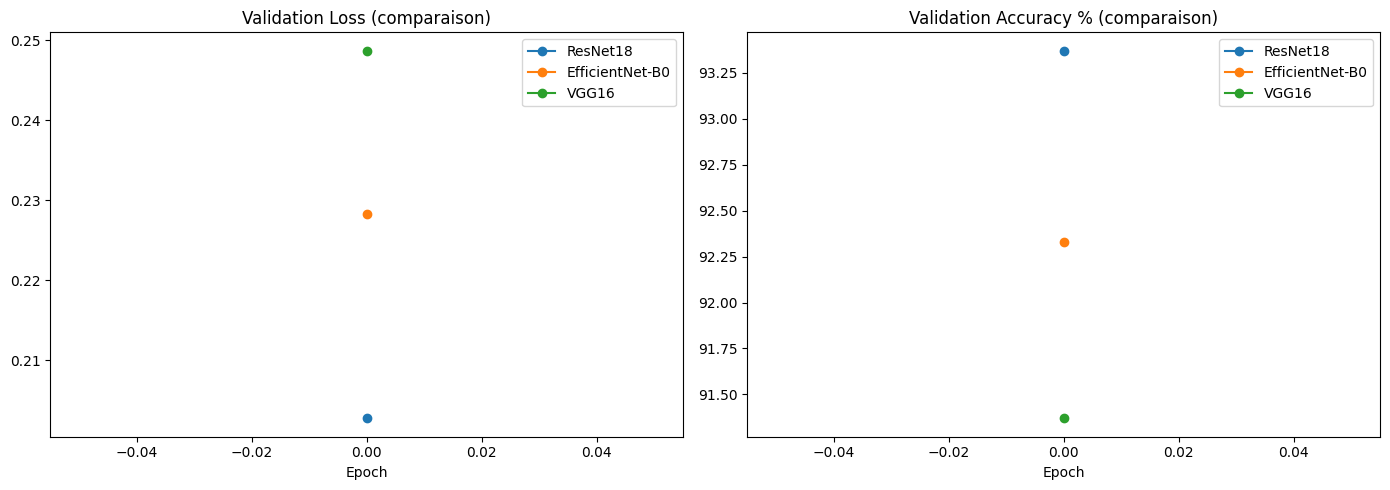

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

histories = {
    'ResNet18'       : resnet_history,
    'EfficientNet-B0': efficientnet_history,
    'VGG16'          : vgg16_history
}

for name, h in histories.items():
    axes[0].plot(h['val_loss'], label=name, marker='o')
    axes[1].plot(h['val_acc'],  label=name, marker='o')

axes[0].set_title('Validation Loss (comparaison)'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Validation Accuracy % (comparaison)'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

---
## 8. Fine-Tuning progressif (bonus) — exemple sur ResNet18

**Stratégie en 2 phases** (très efficace en pratique) :
1. **Phase 1** : entraîner seulement la tête (têtes gelées → rapide, stable)
2. **Phase 2** : dégeler tout le réseau et fine-tuner avec un LR très faible

══ Phase 1 : Feature Extraction (backbone gelé) ══
  Paramètres entraînables :    133,898
  Paramètres gelés        : 11,176,512
  Total                   : 11,310,410
  Epoch 01/1 | Train Loss: 0.5699 Acc: 79.93% | Val Loss: 0.4171 Acc: 85.34% | 107.7s

══ Phase 2 : Fine-Tuning complet (LR=1e-5) ══
  Paramètres entraînables : 11,310,410
  Paramètres gelés        :          0
  Total                   : 11,310,410
  Epoch 01/1 | Train Loss: 0.2993 Acc: 89.29% | Val Loss: 0.2419 Acc: 91.33% | 219.1s


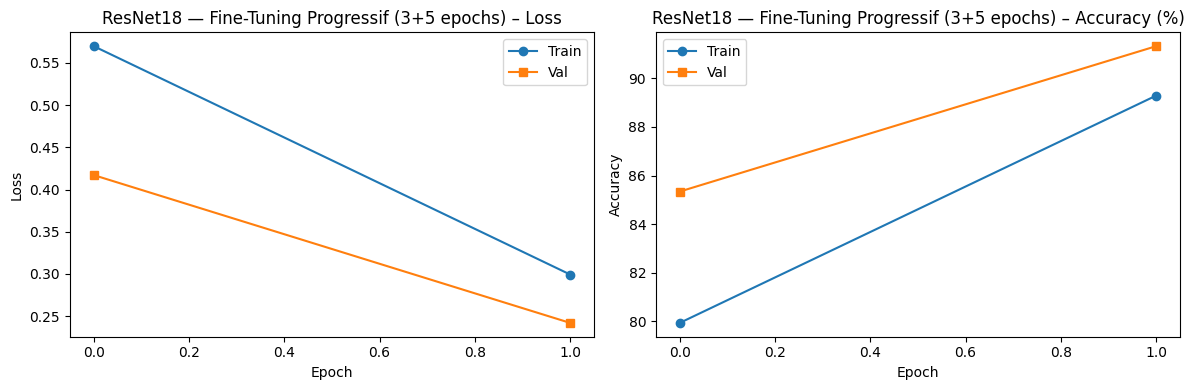

In [19]:
# ── Recréer ResNet18 propre ─────────────────────────────────────────────────
resnet_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
freeze_all(resnet_ft)
resnet_ft.fc = nn.Sequential(
    nn.Linear(resnet_ft.fc.in_features, 256),
    nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)
resnet_ft = resnet_ft.to(device)

# ── PHASE 1 : seule la tête est entraînable ─────────────────────────────────
print("══ Phase 1 : Feature Extraction (backbone gelé) ══")
count_parameters(resnet_ft)
h1 = train_model(resnet_ft, train_loader, test_loader, epochs=1, lr=1e-3)

# ── PHASE 2 : dégeler tout + fine-tuning LR très faible ────────────────────
print("\n══ Phase 2 : Fine-Tuning complet (LR=1e-5) ══")
unfreeze_all(resnet_ft)
count_parameters(resnet_ft)
h2 = train_model(resnet_ft, train_loader, test_loader, epochs=1, lr=1e-5)

# Historique combiné
combined = {k: h1[k] + h2[k] for k in h1}
plot_history(combined, 'ResNet18 — Fine-Tuning Progressif (3+5 epochs)')

---
## 9. Résumé des concepts — Gel des couches

```python
# ① Geler TOUT le modèle
for param in model.parameters():
    param.requires_grad = False

# ② Dégeler une sous-couche spécifique
for param in model.layer4.parameters():
    param.requires_grad = True

# ③ Remplacer et entraîner seulement la tête
model.fc = nn.Linear(512, 10)          # requires_grad=True par défaut

# ④ Passer uniquement les paramètres actifs à l'optimiseur
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# ⑤ Vérifier quels paramètres sont entraînables
for name, param in model.named_parameters():
    print(name, param.requires_grad)
```

| Stratégie | Couches gelées | Couches libres | Quand l'utiliser |
|---|---|---|---|
| Feature Extraction | Tout sauf tête | Nouvelle tête | Dataset très petit |
| Fine-Tuning partiel | Premières couches | Dernières + tête | Dataset moyen |
| Fine-Tuning complet | Aucune | Tout le réseau | Grand dataset |
| Progressif (2 phases) | Phase 1 : tout sauf tête | Phase 2 : tout | Meilleur compromis |
